# Public Health Informatics (part 1)
## Asthma quality measures
The purpose of this module is to introduce you to some basic concepts for working with data:
* Importing Python libraries
* Data frames
* Cleaining data
* Visualizations

## Python libraries
When developing a code base, you will want to make use of code that has already been developed, called libraries.
The general form for importing a library is:
```python
import <library>
```
Sometimes it is convenient to give the library a shortened name so that you can reference it more easily. Here is an example in which I import the Pandas library and give it the alias 'pds':
```python
import pandas as pds
```
Pandas is a very handy library for working with data. We will use it extensively.

In the code cell cell below, you see that I am importing two libraries for working with data (pandas and numpy) and two libraries for making visualizations.
You can import libararies anywhere in your code, but by convention they are usually imported near the top of the notebook so that you can easily find them.

In the cells, the hash sign (`#`) is used to create comments. Comments are not executed, and are used to help explain the code. When you place a hash sign in the code cell, everything after the hash sign is not exectuted.

To execute a code cell, you can press the **shift** and **enter** keys together.

To tell Juypter to import the libraries, navigate to the code cell and press **shift** and **enter** keys.

In [2]:
## libaries for working with data
import pandas as pds
import numpy as np

## libraries for visualizations
import matplotlib.pyplot as plt
import altair as alt
alt.renderers.enable('notebook')

RendererRegistry.enable('notebook')

## Loading data
In order to work with data, the first thing you need to do is load it into some data structure. We well be using the dataframe data structre found in the Pandas library (https://pandas.pydata.org/pandas-docs/stable/).
There is a **mountain** of information available about Pandas. If you get lost or confused just remember that **GOOGLE is your friend**.

In this project, I have included a deidentified Excel file contained various quality measures from some physicians' offices. To load the file, we first load the file using Pandas ExcelFile function:
```python
qm_file = pds.ExcelFile("quality_measures_data.xlsx")
```
**Note:** I am using the alias 'pds' to call the ExcelFile funciton. If I had decided not to define an alias, the `ExcelFile` function would have been called using:
```python
qm_file = pandas.ExcelFile("quality_measures_data.xlsx")
```
Navigate to code cell below and execute.

In [3]:
## load whole excel file deid quality measure data
qm_file = pds.ExcelFile("quality_measures_data.xlsx")

After the Excel file is loaded, you need to specify the sheet within the file has the data you need.
This is done by passing the name of sheet into the parse method.

The parse method returns a Pandas dataframe. In the following code, the variable `df` holds the dataframe created by parsing the "Asthma" sheet in quality_measures_data.xlsx. 

The columns in `df` hold values for the following kinds of data:
* `Quarter`: The quarter of the year during which the data was collected.
* `Site ID`: A string that identifies the site/location at which a provider practices.
* `Group ID`: A string that identifies the group to which a provider belongs.
* `Provider ID`: A string that identifies a provider.
* `Asthma Patients`: The number of patients with asthma that were treated by the provider.
* `Inhaler Prescribed`: The number of patients prescribed a corticosteriod inhaler.
* `Spiro 1 yr`: The number of patients given a spirometry test within the past year.

The `head` method displays the first 5 rows of dataframe.

In [4]:
## load asthma sheet from qm file
df = qm_file.parse("Asthma")
df.head()

,Quarter,Site ID,Group ID,Provider ID,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
0,Q1 2017,S1,G1,P1,3.0,1.0,0.0
1,Q1 2017,S1,G1,P2,96.0,47.0,7.0
2,Q1 2017,S1,G1,P3,18.0,7.0,2.0
3,Q1 2017,S1,G1,P5,198.0,88.0,9.0
4,Q1 2017,S1,G2,P6,75.0,32.0,6.0


In [5]:
for col in df.columns:
    print("'", col , "'")

' Quarter '
' Site ID '
' Group ID '
' Provider ID '
' Asthma Patients '
' Inhaler Prescribed '
' Spiro 1 yr '


## Cleaning column names
When importing data from spreadsheets, the column names in the spreasheet can be difficult to work with. For example, this code grabs the columns from our dataframe `df` and puts a single apostraphe (') around them:
```python
for col in df.columns:
    print("'", col , "'")
```
As you can see from the below output, the column names are surround by spaces:
```
' Quarter '
' Site ID '
' Group ID '
' Provider ID '
' Asthma Patients '
' On appropriate Drug '
' Spiro 1 yr '
```
This can make typing column names a pain. So, we can remove these extra spaces by calling `str.strip()` on each column name:
```python
cleaned_columns = df.columns.str.strip()
```
and assigning the cleaned columns names to the dataframe:
```python
df.columns = cleaned_columns
```
We can now see the new column names by executing `print(df.columns)`, having output:
```
Index(['Quarter', 'Site ID', 'Group ID', 'Provider ID', 'Asthma Patients',
       'On appropriate Drug', 'Spiro 1 yr'],
      dtype='object')
```
Navigate to code cells below and execute.

In [6]:
## column names may have leading/trailing spaces
## so do some cleanup to make working with columns easier to work with
cleaned_columns = df.columns.str.strip()

In [7]:
df.columns = cleaned_columns
print(df.columns)

Index(['Quarter', 'Site ID', 'Group ID', 'Provider ID', 'Asthma Patients',
       'Inhaler Prescribed', 'Spiro 1 yr'],
      dtype='object')


## Subsetting data
For this notebook, we are only going to work with data from the second quarter of 2018. This data is identified by the value 'Q2 2018' in the **Quarter** column of our dataframe.

There are two ways to retrieve this **subset** of data. This is often called **subsetting**:

1. Specify the subset criterial inside brackets:
```python
df[df.Quarter == 'Q2 2018']
```
2. Use Pandas dataframes **query** method:
```python
df.query("Quarter == 'Q2 2018'")
```

Both methods are equivalent, and I alternate between each.

**Note**: You need to use '==' **NOT** '='. '==' is used to test for equality. '=' is used to assign values.

In the code cell below, I subset our datafame `df` and assign this subset to a new dataframe named `df_quarter`.

In [8]:
## for now, let's focus on data from Q2 2018
## when fields don't have spaces, you can use the dot notation to access field names
## note: the use of '==' and not '='
df_quarter = df[df.Quarter == 'Q2 2018']
df_quarter.head()

,Quarter,Site ID,Group ID,Provider ID,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
72,Q2 2018,S1,G1,P1,8.0,1.0,1.0
73,Q2 2018,S1,G1,P2,96.0,40.0,13.0
74,Q2 2018,S1,G1,P3,13.0,5.0,0.0
75,Q2 2018,S1,G1,P5,23.0,12.0,0.0
76,Q2 2018,S1,G2,P6,140.0,58.0,14.0


## Data cleaning
Data is often messy. Values can be missing (represented as an `NaN` in the data) or the data may not make sense (e.g., a person's age being less than 0). For now, let's focus on missing values.

One way you can find missing values is to execute the isnull() method on a dataframe, e.g.:
```python
df_quarter.isnull()
```
This will return a dataframe of `True/False` values:
<img src="images/isnull_dataframe.png" width="600px"/> 

Cells with `True` values are missing.

As you can see, finding a `True` value might be difficult. In the above example, a `True` value doesn't occur until index (or row) 79. In this row, the values in columns '

A quicker method is to excute `df_quarter.isnull().values.any()`:
```python
True
```

This simply returns `True` if one of the values in `df_quarter` is `NaN`.

If you want to see which indexes (or rows) have `NaN` values, you can execute the following:
```python
df_quarter[df_quarter.isnull().any(axis=1)]
```
This subsets `df_quarter` to only include those rows where `isnull()` has returned `True`. The `axis=1` parameter specifies that rows will be returned.
<img src="images/null_dataframe_rows.png" width="600px"/> 

Navigate to code cells below and execute.

In [9]:
## a quick way to determine if there are missing values
df_quarter.isnull().values.any()

True

In [10]:
df_quarter[df_quarter.isnull().any(axis=1)]

,Quarter,Site ID,Group ID,Provider ID,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
79,Q2 2018,S1,G2,P9,NaN,NaN,NaN
86,Q2 2018,S2,G3,NaN,1386.0,557.0,231.0


## Replacing missing values
If you determine the dataset has missing values (i.e. `NaN` values), the next step is to decide how you want to replace them.

The simplest method is to use Pandas `fillna` method (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html)

Execute the cell below to replace all `NaN` values with a `0` and assign to a new dataframe `df_fillna`.
Typically, I output operations like this into a new dataframe so that I can easily go back an exam the original dataset.

In [11]:
## replace NaNs with a 0s
df_fillna = df_quarter.fillna(0)

In [12]:
## test for presence of any Nan values
df_fillna.isnull().values.any()

False

## Missing Provider ID
If you examine the `df_quarter` dataframe, you will notice one of the `Provider ID`s was missing:
<img src="images/null_dataframe_rows.png" width="600px"/> 

Our call to `fillna(0)` replaced this a `0`. 
<img src="images/provider_0_dafaframe.png" width="600px"/>

However, since `Provider ID`s are not (in general) the kinds of things we perform mathematical operations on (e.g., add, substract, mulitply), having a value of `0` might be misleading. 

So, rather than using `0` for the missing `Provider ID`, I will use the value `No ID`.


## Lambda functions
I am going to replace the missing `Provider ID` using a Lambda (as called an anonymous) function. Basically, a lambda function is a function without a name (hence, why they are called "anonymous").

Typically, functions are defined using the syntax `def <function name>`. For example:
```python
def myfunction(x)
    return x + 1
```
The name of the function is `myfunction`.

The above syntax for defining a function is a kind of syntactic shortcut for assigning a function the variable `myfunction`. If we wish, we could have defined this function using:
```python
myfunction = lambda x: x + 1
```

To execute `myfunction`, you simply call the function as you normally would:
```python
myfunction(3)
4 # call to myfunction returns value 4
```

Hopefully, this gives you a sense of what lambda functions are. More information can be found here: https://www.w3schools.com/python/python_lambda.asp



## Using lambda functions
A nice use of lambda functions is to map a function over a column in a dataframe. For example, suppose I want to call `myfunction` on every value in particulary column in dataframe `my_df`. For this, I can define a lambda funciton, and use the map method:
```python
my_df['some column name'].map(lambda x: x + 1)
```

There two advantages to doing this:
1. Pandas map method has been optimized to work efficiently with dataframes. So, although the same task can be accomplished by iterating (i.e., looping) over the values, map runs faster in many cases.
2. I do not have to define a function for an ad hoc task. This is useful when a function is only used once.


Here is an article about using lambda functions to clean data: https://medium.com/@chaimgluck1/have-messy-text-data-clean-it-with-simple-lambda-functions-645918fcc2fc


In [13]:
## find the row in which Provider ID has value of 0
df_fillna[df_fillna['Provider ID'] == 0]

,Quarter,Site ID,Group ID,Provider ID,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
86,Q2 2018,S2,G3,0,1386.0,557.0,231.0


## Lambda if / else
Exeduting a lambda function on the `Provider ID` colum requires that we only change the values that equal `0`. Conceptually, you want to do something like:
```
if id != 0 # '!=' means not equal
    return id
else
    return 'No ID'
```
However, you can't do this in lambda functions. Instead, you need to use the construct `x if <condition == true> else y`, meaning that `x` is returned if your condition evaluates to true; otherwise return `y`. 

Finally, to change `Provider ID` values of `0`, we need a lambda function that works like so:
```
lambda x: x if x != 0 else 'No ID'
```
Execute the code cells below to see this code implemented.

In [14]:
## use a lambda function to change values of "0" to "No ID"
df_fillna['Provider ID'] = df_fillna['Provider ID'].map(lambda x: x if x != 0 else 'No ID')

In [15]:
## very new value is "No ID"
df_fillna.query('index == 86')

,Quarter,Site ID,Group ID,Provider ID,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
86,Q2 2018,S2,G3,No ID,1386.0,557.0,231.0


## Group totals
Now that our data has been cleaned, we can do some simple analysis. 

Each of the providers in our dataset has been placed in one of three groups: `G1`, `G2`, `G3`. We want to know how many asthma patients are in each group, and how many tests were given.

For this we are going to make use of Panda's `pivot_table` method. This method is really handy for aggregating groups of values. Documentation on it is found here: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html

For our purposes, I will define the following:
* An array of column names that contain the data we want to work with. For example, we want to determine the total number of patients in `Asthma Patients` column, but we are not interested in the values of the `Quarter` column.
* Which column values we will use as our index (or rows identitifer). In this case, we want the `Group ID` column.
* The function to use for aggregating values. We will the `sum` function from the `Numpy` libarary.

After executing the code cell below, the variable `group_totals` contains a datafame with the totals for each group of data values.

Here is more information about `pivot_table`: https://www.dataquest.io/blog/pandas-pivot-table/

In [16]:
## define a variable with the column names of the values we want to aggregate
data_cols = ['Asthma Patients', 'Inhaler Prescribed', 'Spiro 1 yr']

## sum the totals for each group using groupby
group_totals = pds.pivot_table(df_fillna, values=data_cols, index=['Group ID'], aggfunc=np.sum)


In [17]:
group_totals ## show output


,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
Group ID,,,
G1,140.0,58.0,14.0
G2,394.0,148.0,50.0
G3,1386.0,557.0,231.0


## Ratios and vector operations
Now we have totals, let's found out the ratios of ashtma patients that were prescribed a steroid inhaler or have had a spirometry test within the past year.

To capture this information, we will create a new dataframe named `group_pct` to hold the percentages. To calculate these ratios, you need to divide the number of patients prescribed an ihaler by the total number of patients, and likelwise for the ratio of patients given a spirometry test. One way to do this, would be to iterate over each row in the dataframe on calculate the ratio. Something like this:
```python
for idx, asthma_pts, inhaler_rx, spiro in group_totals.itertuples():
    inhaler_ratio = inhaler_rx / asthma_pts
    spiro_ration = spiro / asthma_pts
```
However, Pandas allows you perform operations on how whole vectors. For example, you can add the elements of two arrays by simply doing an add operation instead of iterating over each array:
```python
array_1 = np.array([1, 2, 3, 4])
array_2 = np.array([5, 6, 7, 8])
array_3 = array_1 * array_2 # array_3 is now [ 5, 12, 21, 32]
```
So, instead of iterating over the group_totals dataframe, we will use vector operations; e.g.:
```python
group_pct['Inhaler Prescribed'] = group_totals['Inhaler Prescribed'] / group_totals['Asthma Patients']
```
Vector operations can result in significant performance improvements. Here is a tutorial about it: https://engineering.upside.com/a-beginners-guide-to-optimizing-pandas-code-for-speed-c09ef2c6a4d6

Because our dataset is small we won't gain any noticable performance improvements, but it still has the adavantage of making the code cleaner and easier to understand.

Execute the code cell below to create a datafame to contain the percentages.

In [18]:
## create dataframe of percentages
group_pct = group_totals.copy() # create copy of totals

## calculate ratios
group_pct['Inhaler Prescribed'] = group_totals['Inhaler Prescribed'] / group_totals['Asthma Patients']
group_pct['Spiro 1 yr'] = group_totals['Spiro 1 yr'] / group_totals['Asthma Patients']

group_pct


,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
Group ID,,,
G1,140.0,0.414286,0.100000
G2,394.0,0.375635,0.126904
G3,1386.0,0.401876,0.166667


## Convert ratios to percentages
Our dataframe `group_pct` now contains decimal values of the ratios. To convert these into percentages, we will multiply each ratio by 100 and round to two decimal places.

Below, we do this by (again) using lambda functions to convert each values.

In [19]:
## turn decimals in percents and round
group_pct['Inhaler Prescribed'] = group_pct['Inhaler Prescribed'].map(lambda x: round(x * 100, 2))
group_pct['Spiro 1 yr'] = group_pct['Spiro 1 yr'].map(lambda x: round(x * 100, 2))
group_pct


,Asthma Patients,Inhaler Prescribed,Spiro 1 yr
Group ID,,,
G1,140.0,41.43,10.00
G2,394.0,37.56,12.69
G3,1386.0,40.19,16.67


## Visualizations
Tables of data are nice, but often it is useful to visualize the data. For example, below is the code usin the matplotlib library (alias `plt`) to show a pie chart of groups. Documentation about matplotlib can be found here:
https://matplotlib.org/
https://matplotlib.org/api/_as_gen/matplotlib.pyplot.pie.html

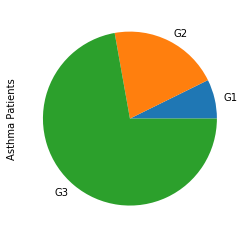

In [20]:
## simple pie chart of number of asthma patients per group
group_pct['Asthma Patients'].plot.pie()
plt.show()


## Data prep for visualizations
Before constucting visualizations, it is often necessary to prepare (or transform) the data into a structure needed by the visualization library.

One common operation is reshape the dataframe so that the column names become values with the values in another column. Explaining this in words is difficult, so it best understood by working through the code below. I use Panda's `melt` method (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html) to create a column named `Measure` that has values the column names from `group_pct` and column named `Percent` that holds the percentage values.


In [21]:
data = pds.melt(group_pct.reset_index(), 
                id_vars=['Group ID', 'Asthma Patients'], 
                var_name='Measure', value_name='Percent')

In [22]:
data

,Group ID,Asthma Patients,Measure,Percent
0,G1,140.0,Inhaler Prescribed,41.43
1,G2,394.0,Inhaler Prescribed,37.56
2,G3,1386.0,Inhaler Prescribed,40.19
3,G1,140.0,Spiro 1 yr,10.00
4,G2,394.0,Spiro 1 yr,12.69
5,G3,1386.0,Spiro 1 yr,16.67


## Bar charts
The dataframe `data` is now has a structure that allows me to easily subset and display the data. In the examples below, I will be using the Altair data visualizaiton library:

https://altair-viz.github.io/getting_started/starting.html

If we want to visualize the percentage of patients having a spirometry test, we subset `data` using `data[data.Measure == 'Spiro 1 yr']` and call Altair's `mark_bar()` method.

Information about basic bar charts is found here:

https://altair-viz.github.io/gallery/simple_bar_chart.html

Notice that in addition to drawing the baring chart, I also set other important properties, such as the chart's chart's **title** ,**width**, and **axis titles**. Details about how to set these properties can be found on Altair's website. Also, for readability, I use the `\` character to break up the method call over multiple lines.

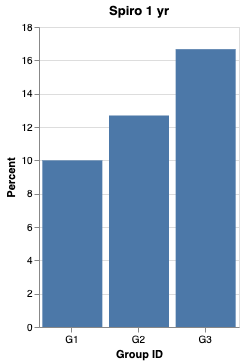

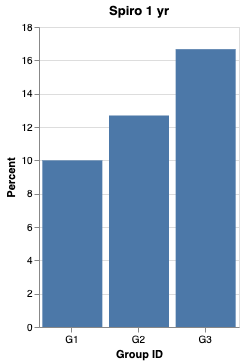

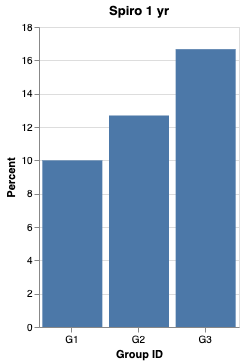

In [23]:
chart = \
  alt.Chart(data[data.Measure == 'Spiro 1 yr'], title="Spiro 1 yr")\
  .mark_bar()\
  .encode(
      x=alt.X('Group ID', axis=alt.Axis(labelAngle=0, title='Group ID')),
      y='Percent'
    )\
  .properties(width=200)
chart.display()

## Bar charts with totals
The above bar chart shows percentages of patients having a spirometry test. However, we've lost information about how many patients took the spirometry test. To add this, we will create a chart (named `text`) of labels showing the number of patients in each group using the chart's `mark_text` method and specifying the `Asthma Patients` column in the `text` parameter of the `encode` method.

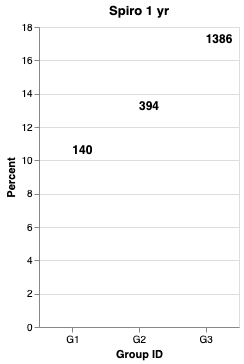

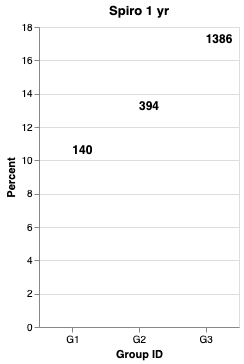

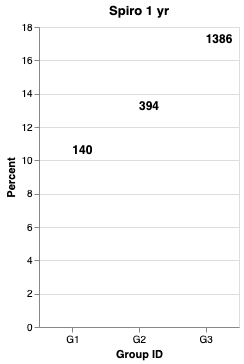

In [24]:
text = \
 chart.mark_text(
      align='left',
      baseline='top',
      fontWeight="bold",
      fontSize=12,
      dy=-15
  ).encode(
      text='Asthma Patients'
  )

text.display() # display the text chart

As you can see, this only produced a chart with labels. To overlay the labels on the bars, we need to create a compound chart. 

In this case, we will call Altair's layer method to place to labels over the bars.

There are a number of different ways to create compound charts (e.g., horizontal concatenation, vertical concatenation). More information is found here: https://altair-viz.github.io/user_guide/compound_charts.html

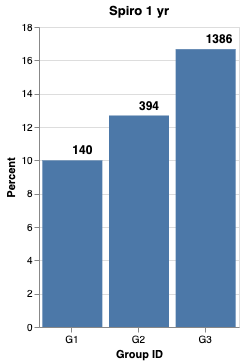

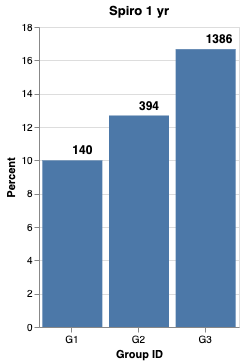

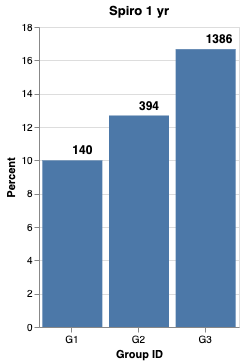

In [25]:
alt.layer(chart, text)


## Color schemes
The default bluish color looks okay. But, if we want to spice things up a little, Alair offers a number of color schemes. A list of these schemes is can be found here:

https://vega.github.io/vega/docs/schemes/

I decided to use hte **viridis** scheme, but try out some of the other schemes and see if you like another. Also, notice that added a legend for identifying the groups: `legend=alt.Legend(title="Groups")`.

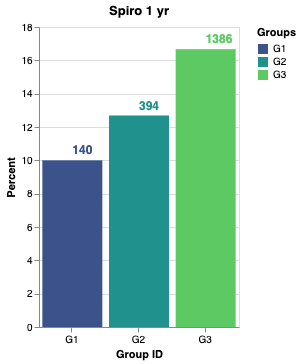

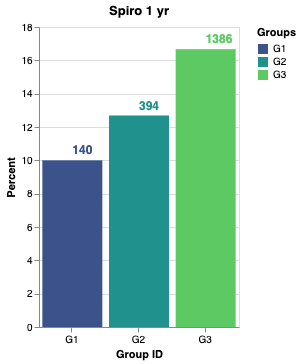

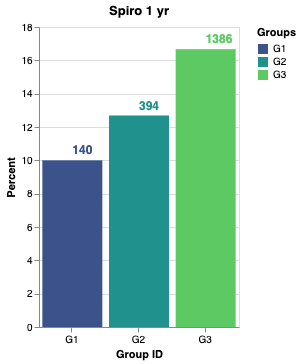

In [26]:
chart = \
  alt.Chart(data[data.Measure == 'Spiro 1 yr'], title="Spiro 1 yr")\
  .mark_bar()\
  .encode(
      x=alt.X('Group ID', axis=alt.Axis(labelAngle=0, title='Group ID')),
      y='Percent',
      color=alt.Color('Group ID', scale=alt.Scale(scheme='viridis'), legend=alt.Legend(title="Groups")))\
  .properties(width=200)

text = \
 chart.mark_text(
      align='left',
      baseline='top',
      fontWeight="bold",
      fontSize=12,
      dy=-15,
    
  ).encode(
      text='Asthma Patients'
  )

spiro_chart = (chart + text) # another way to specify alt.layer(chart, text)
spiro_chart.display()

## Concatenating charts
We now have a chart bringing together the percentage taking a spirometry test and the number of patients in each group. However, our data also includes information about patients being prescribed inhalers. In order to create a chart of this, we can simply make appropriate changes to the spirometry chart (execute code below).

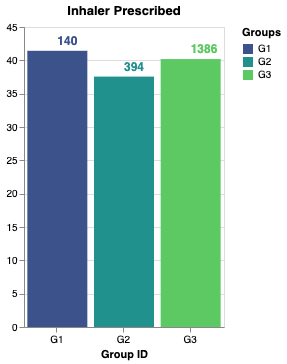

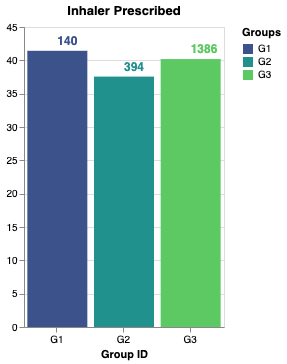

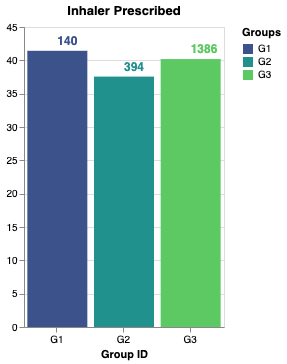

In [27]:
chart = \
     alt.Chart(data[data.Measure == 'Inhaler Prescribed'], title="Inhaler Prescribed")\
     .mark_bar()\
     .encode(
       x=alt.X('Group ID', axis=alt.Axis(labelAngle=0, title='Group ID')),
       # y=alt.Y('Percent', title=None, axis=None), # use this line to hide they y-scale axis
       y=alt.Y('Percent', title=None),
       color=alt.Color('Group ID', scale=alt.Scale(scheme='viridis'), legend=alt.Legend(title="Groups")))\
  .properties(width=200)

text = \
    chart.mark_text(
      align='left',
      baseline='top',
      fontWeight="bold",
      fontSize=12,
      dy=-15
  ).encode(
      text='Asthma Patients'
  )

drug_chart = (chart + text)
drug_chart.display()

But, now we have two separate charts. What about if we wanted to combine the spirometry and inhaler charts?

We briefly discussed concatenating charts when we added patient counts. Now, we will use Altair's `hconcat` method to horizontally concatentate both charts (i.e., place the charts side-by-side).

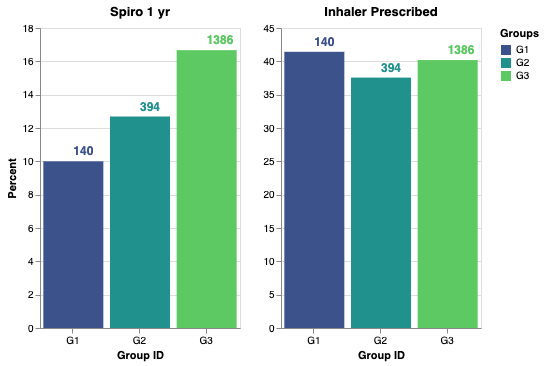

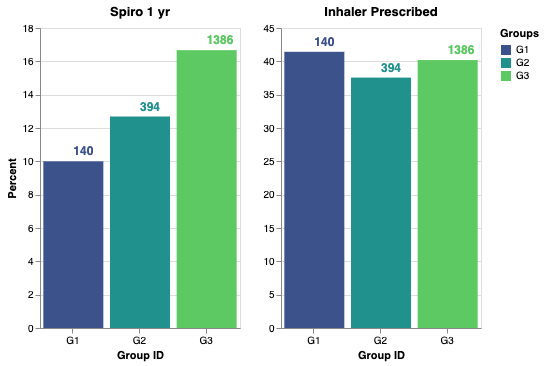

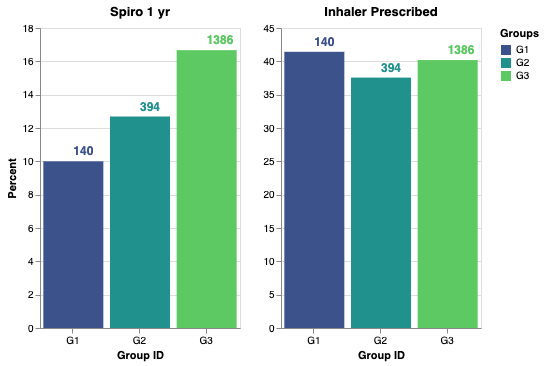

In [28]:
concat_chart = alt.hconcat(spiro_chart, drug_chart) # create a concatentated chart
concat_chart.display()

## Chart facets
Our concatenated chart is better than having two separate charts: the informaiton is now one place; but the chart is easy to misread. They y-scale ranges for each chart are different. The spirometry chart has ranges 0-18, while the inhaler chart has ranges 0-45. However, both charts have the same height. If you are not careful, you may be tempted to make cross-chart comparisons that are wrong. For instance, it "looks" like roughly the same number of patients in `G3` had spirometry tests as patients in `G1` had been prescribed an inhaler. This is far from the truth. The spirometry chart shows that roughly 17% of the `G3`'s 1,386 patients (about 236) had a spirometry test, while the ihaler chart shows that roughly 37% of `G2`'s 394 patients (about 146) had been prescribed an inhaler.

To make the y-scales "line up", will use Altair's facet chart: https://altair-viz.github.io/user_guide/compound_charts.html#faceted-charts

Below, I create a facet chart using the `Measure` column from our dataset: `.facet(column=alt.Column('Measure', sort=order_cols))`

To set the order in which charts are displayed, I create an `order_cols` variable to use in the `sort` parameter. If you don't specify this, Altair will determine the order. I also change the color scheme to `category10`.

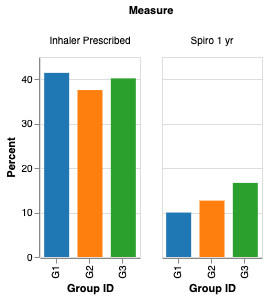

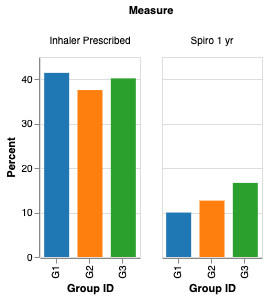

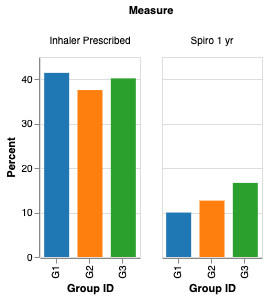

In [29]:
order_cols = ['Inhaler Prescribed', 'Spiro 1 yr']

chart = alt.Chart(data)
chart.mark_bar(size=25)\
     .encode(x='Group ID',
             y='Percent',
             color=alt.Color('Group ID', legend=None, scale=alt.Scale(scheme='category10')))\
     .properties(width=100, height=200)\
     .facet(column=alt.Column('Measure', sort=order_cols))

## Facets with totals
The facet chart now has the advantage of using the same y-scale for both spirometry and inhaler charts. But, we have now lost information about how many patients are in each group.

Unfortunately, Altair facet chart does **not** currently allow you to insert labels above the bars. So, instead of using text labels, first I create a bart chart of the number of asthma patients in each group (execute code below).

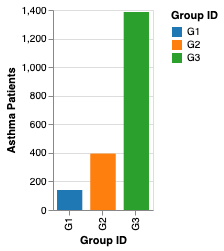

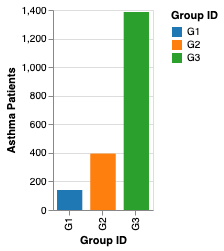

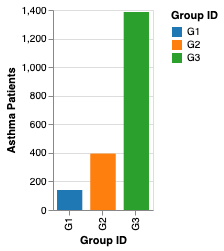

In [30]:
count_chart = \
    alt.Chart(data)\
    .mark_bar(size=25)\
    .encode(
        x='Group ID',
        y='Asthma Patients',
        color=alt.Color('Group ID', scale=alt.Scale(scheme='category10')))\
    .properties(width=100, height=200)

count_chart.display()

Second, I horizontally concatenate the asthma patient chart to the previous spirometery and ihaler charts (execute code below).

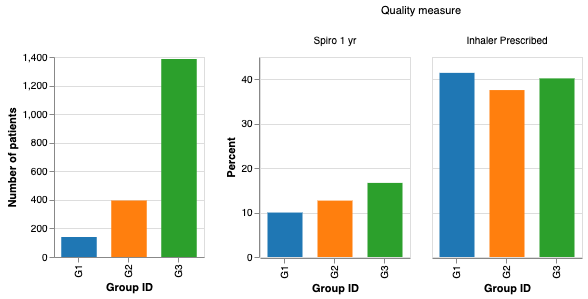

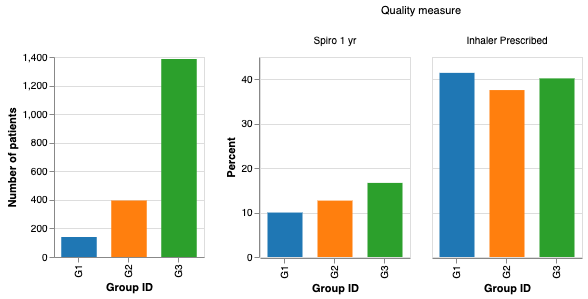

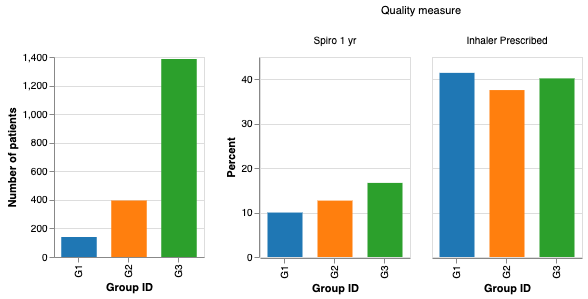

In [31]:
order_cols = ['On appropriate Drug', 'Spiro 1 yr']

chart = \
    alt.Chart(data)\
    .mark_bar(size=35)\
    .encode(x='Group ID',
         y='Percent',
         color=alt.Color('Group ID', scale=alt.Scale(scheme='category10'), legend=None))\
    .properties(width=150, height=200)\
    .facet(column=alt.Column(
        'Measure', 
        sort=order_cols, 
        title="Quality measure", 
        header=alt.Header(titleFontWeight="normal")))

count_chart = \
    alt.Chart(data)\
    .mark_bar(size=35)\
    .encode(
        x=alt.X('Group ID'),
        y=alt.Y('Asthma Patients', title="Number of patients"),
        color=alt.Color('Group ID', scale=alt.Scale(scheme='category10'), legend=None))\
    .properties(width=150, height=200)\

# num_chart.display()
alt.hconcat(count_chart, chart)\
    .configure_title(orient="top", anchor="middle")


## Wrapping up
In this notebook, I have covered a number of topics:
* Importing libraries
* Loading data
* Pandas dataframes
* Cleaning data
* Visualizing data

These topics also introduced a number of important methods and operations central to using Pandas:
* Lambda functions
* Pivot tables
* Melt function
* Vector operations

Finally, I introduced some visualization methods for:
* Pie charts
* Bar charts
* Facet charts

This has only scratched the surface for these topics. In particular, there is still a lot you can explore about how to visulize the data. There a number of different visualization libraries (e.g., Seaborn is another popular option), but each library has tradeoffs between its ease of use and power. I encourage you to explore these features on your own.